# Análisis del entorno ALE/SpaceInvaders-v5

Análogo al EDA de un problema supervisado, antes de entrenar cualquier agente. Cubre: estructura de recompensa, histograma y longitud de episodios, vidas, `terminated` vs `truncated`, significado de las acciones, paleta de colores y línea base de agente aleatorio.

In [1]:
import sys, os
sys.path.append(os.path.abspath("../src"))

import ale_py
import gymnasium as gym
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter, deque

from entorno import crear_entorno_preprocesado, crear_entornos_vectorizados, NOMBRE_ENTORNO
from ale_utils import ejecutar_episodio

plt.rcParams["figure.figsize"] = (10, 4)

## 1. Descripción general

- **Objetivo del juego:** destruir invasores que descienden en formación; cada invasor derribado da puntos según su fila.
- **Fin de episodio:** perder las 3 vidas (`terminated`) o agotar el límite de tiempo del escenario (`truncated`).
- **Observación cruda:** imagen RGB de 210x160.
- **Espacio de acción:** `Discrete(6)` con `full_action_space=False`.

Observación: Box(0, 255, (210, 160, 3), uint8)
Acciones: Discrete(6)
Significados: ['NOOP', 'FIRE', 'RIGHT', 'LEFT', 'RIGHTFIRE', 'LEFTFIRE']
Vidas iniciales: 3


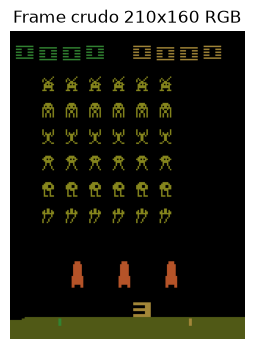

In [2]:
env_crudo = gym.make(NOMBRE_ENTORNO)
print("Observación:", env_crudo.observation_space)
print("Acciones:", env_crudo.action_space)
print("Significados:", env_crudo.unwrapped.get_action_meanings())
print("Vidas iniciales:", env_crudo.unwrapped.ale.lives())
observacion, info = env_crudo.reset(seed=0)
plt.imshow(observacion)
plt.title("Frame crudo 210x160 RGB")
plt.axis("off")
plt.show()

## 2. Estructura de la recompensa: ¿densa o dispersa?

Se registra la recompensa paso a paso en episodios aleatorios. Si la mayoría de los pasos da 0 y el puntaje llega en eventos puntuales, la señal es dispersa; el clipping estándar de Atari la reduce a {-1, 0, 1}.

In [3]:
recompensas_paso = []
episodios_muestra = []
for ep in range(10):
    obs, _ = env_crudo.reset(seed=ep)
    acumulado_ep = []
    terminado = False
    while not terminado:
        obs, r, term, trunc, _ = env_crudo.step(env_crudo.action_space.sample())
        recompensas_paso.append(r)
        acumulado_ep.append(r)
        terminado = term or trunc
    episodios_muestra.append(np.cumsum(acumulado_ep))

recompensas_paso = np.array(recompensas_paso)
print(f"Pasos totales: {len(recompensas_paso)}")
print(f"Fracción de pasos con recompensa != 0: {np.mean(recompensas_paso != 0):.4f}")
print(f"Recompensa por paso: media {recompensas_paso.mean():.4f}, max {recompensas_paso.max()}, valores únicos {np.unique(recompensas_paso)}")

Pasos totales: 4768
Fracción de pasos con recompensa != 0: 0.0161
Recompensa por paso: media 0.2685, max 200.0, valores únicos [  0.   5.  10.  15.  20.  25.  30. 200.]


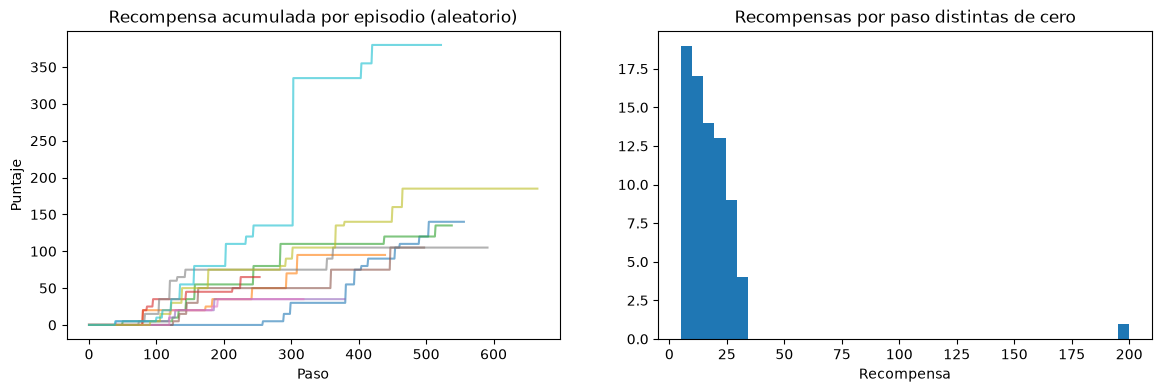

In [4]:
fig, ejes = plt.subplots(1, 2, figsize=(14, 4))
for curva in episodios_muestra:
    ejes[0].plot(curva, alpha=0.6)
ejes[0].set_title("Recompensa acumulada por episodio (aleatorio)")
ejes[0].set_xlabel("Paso")
ejes[0].set_ylabel("Puntaje")
ejes[1].hist(recompensas_paso[recompensas_paso != 0], bins=40)
ejes[1].set_title("Recompensas por paso distintas de cero")
ejes[1].set_xlabel("Recompensa")
plt.show()

## 3. Longitud de episodios y puntaje aleatorio (piso de referencia)

20 episodios con agente aleatorio sobre el entorno preprocesado sin clipping de recompensa y sin terminar el episodio al perder vida, para medir el puntaje real del juego.

In [5]:
def agente_aleatorio(observacion, env):
    return env.action_space.sample()

env_eval = crear_entorno_preprocesado(escala_grises=True, vida_termina_episodio=False, recorte_recompensa=False)
resultados = [ejecutar_episodio(env_eval, agente_aleatorio) for _ in range(20)]
env_eval.close()

df_base = pd.DataFrame(resultados)
puntajes = df_base["recompensa_total"]
print(df_base.describe())
print(f"Puntaje aleatorio: media {puntajes.mean():.1f}, max {puntajes.max():.0f}, min {puntajes.min():.0f}")
print(f"Longitud de episodio: media {df_base['pasos'].mean():.0f} pasos (x4 frames internos del skip = {df_base['pasos'].mean()*4:.0f} frames de juego)")

            pasos  recompensa_total
count   20.000000         20.000000
mean   459.950000        129.750000
std    118.762689         86.106956
min    267.000000         30.000000
25%    382.750000         72.500000
50%    474.500000        102.500000
75%    535.500000        185.000000
max    686.000000        330.000000
Puntaje aleatorio: media 129.8, max 330, min 30
Longitud de episodio: media 460 pasos (x4 frames internos del skip = 1840 frames de juego)


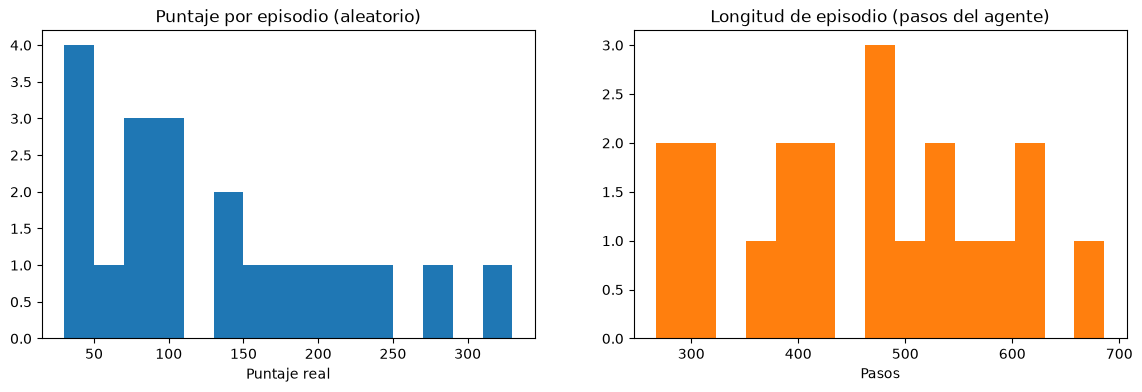

In [6]:
fig, ejes = plt.subplots(1, 2, figsize=(14, 4))
ejes[0].hist(puntajes, bins=15)
ejes[0].set_title("Puntaje por episodio (aleatorio)")
ejes[0].set_xlabel("Puntaje real")
ejes[1].hist(df_base["pasos"], bins=15, color="tab:orange")
ejes[1].set_title("Longitud de episodio (pasos del agente)")
ejes[1].set_xlabel("Pasos")
plt.show()

## 4. Vidas y `terminated` vs `truncated`

El entorno crudo tiene 3 vidas. El wrapper `EpisodicLifeEnv` de SB3 reporta `terminated=True` al perder una vida, lo que acorta el horizonte de aprendizaje; el episodio real continúa. Aquí se mide cuántas muertes hay por episodio real.

In [7]:
muertes_totales = []
for ep in range(5):
    obs, _ = env_crudo.reset(seed=100 + ep)
    vidas = 3
    muertes = 0
    terminado = False
    while not terminado:
        obs, r, term, trunc, _ = env_crudo.step(env_crudo.action_space.sample())
        vidas_actuales = env_crudo.unwrapped.ale.lives()
        if vidas_actuales < vidas:
            muertes += vidas - vidas_actuales
            vidas = vidas_actuales
        terminado = term or trunc
    muertes_totales.append(muertes)
    print(f"Episodio {ep}: {muertes} pérdidas de vida, terminated={term}, truncated={trunc}")
print(f"Pérdidas de vida por episodio real: media {np.mean(muertes_totales):.1f}")

Episodio 0: 3 pérdidas de vida, terminated=True, truncated=False


Episodio 1: 3 pérdidas de vida, terminated=True, truncated=False


Episodio 2: 3 pérdidas de vida, terminated=True, truncated=False


Episodio 3: 3 pérdidas de vida, terminated=True, truncated=False


Episodio 4: 3 pérdidas de vida, terminated=True, truncated=False
Pérdidas de vida por episodio real: media 3.0


`terminated` marca el fin real del juego (0 vidas) y `truncated` el límite artificial de pasos. Con agente aleatorio no se alcanza el truncamiento. En entrenamiento, `EpisodicLifeEnv` convierte cada pérdida de vida en fin de episodio: se entrena con episodios más cortos y horizonte menor.

## 5. Preprocesamiento para la red

- Escala de grises 84x84 (1 canal), apilado de 4 frames: forma final `(4, 84, 84)`.
- Variante RGB para la ablación: 4 frames x 3 canales = `(12, 84, 84)`.
- Salto de frames de 4 con max-pooling, no-op aleatorio al inicio, FIRE al reset, clipping de recompensa, fin de episodio al perder vida.

Forma con grises: (1, 4, 84, 84)
Forma con RGB: (1, 12, 84, 84)


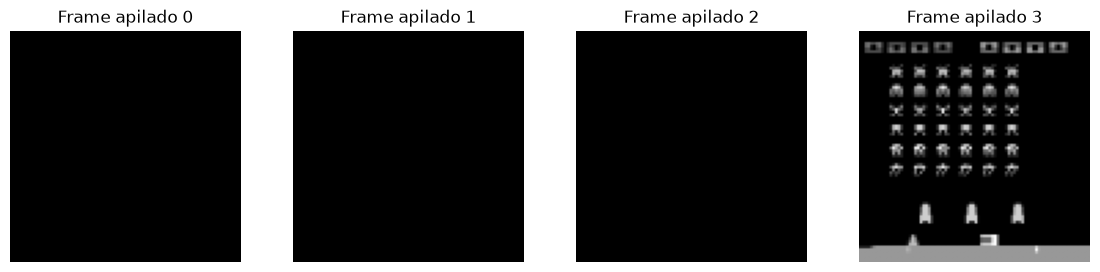

In [8]:
vec_gris = crear_entornos_vectorizados(semilla=0, escala_grises=True)
vec_rgb = crear_entornos_vectorizados(semilla=0, escala_grises=False)
print("Forma con grises:", vec_gris.reset().shape)
print("Forma con RGB:", vec_rgb.reset().shape)
obs_gris = vec_gris.reset()[0]
fig, ejes = plt.subplots(1, 4, figsize=(14, 3))
for i, eje in enumerate(ejes):
    eje.imshow(obs_gris[i], cmap="gray")
    eje.set_title(f"Frame apilado {i}")
    eje.axis("off")
plt.show()
vec_gris.close()
vec_rgb.close()

## 6. Paleta de 7 colores y conversión a escala de grises

Hipótesis de ADR-002: los colores del juego mapean a niveles de gris distintos, de modo que la conversión no colisiona objetos. Se recopilan los colores frecuentes en frames crudos y se verifica que la proyección a gris sea inyectiva sobre esa paleta.

In [9]:
env_paleta = gym.make(NOMBRE_ENTORNO, render_mode="rgb_array")
contador = Counter()
for ep in range(10):
    obs, _ = env_paleta.reset(seed=200 + ep)
    for paso in range(2000):
        obs, _, term, trunc, _ = env_paleta.step(env_paleta.action_space.sample())
        contador.update(map(tuple, obs.reshape(-1, 3)[::3]))
        if term or trunc:
            break
env_paleta.close()

paleta = [color for color, cantidad in contador.most_common(8) if color != (0, 0, 0)][:7]
tabla = pd.DataFrame(
    {
        "color": [f"#{r:02x}{g:02x}{b:02x}" for r, g, b in paleta],
        "rgb": paleta,
        "nivel_gris": [round(0.299 * r + 0.587 * g + 0.114 * b) for r, g, b in paleta],
        "frecuencia": [contador[c] for c in paleta],
    }
)
print(tabla.to_string(index=False))
niveles = tabla["nivel_gris"].to_numpy()
assert len(set(niveles)) == len(niveles), "Colisión de niveles de gris en la paleta"
print(f"Los {len(paleta)} colores mapean a {len(set(niveles))} niveles de gris distintos: conversión inyectiva")

  color             rgb  nivel_gris  frecuencia
#505916    (80, 89, 22)          79     4515240
#86861d  (134, 134, 29)         122     2169768
#b55328   (181, 83, 40)         107      467183
#328432   (50, 132, 50)          98      415643
#a28638  (162, 134, 56)         133      378118
#8e8e8e (142, 142, 142)         142        9550
#97197a  (151, 25, 122)          74        4938
Los 7 colores mapean a 7 niveles de gris distintos: conversión inyectiva


## 7. Conclusiones del análisis

- La recompensa es mayormente dispersa: la mayoría de pasos da 0, con eventos de puntaje al derribar invasores.
- El clipping estándar de Atari a {-1, 0, 1} se aplica en entrenamiento; la evaluación se reporta con recompensa real.
- Con agente aleatorio, los episodios son cortos por las pérdidas de vida; el piso de referencia queda registrado arriba.
- La conversión a escala de grises es inyectiva sobre la paleta del juego: no pierde identidad de objetos, lo que justifica entrenar en grises (ADR-002).
- Se entrena con `full_action_space=False` (6 acciones) y `EpisodicLifeEnv` activo.